In [ ]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm

In [ ]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emirhanai/human-action-detection-artificial-intelligence")

print("Path to dataset files:", path)

100%|██████████| 147M/147M [00:02<00:00, 56.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/emirhanai/human-action-detection-artificial-intelligence/versions/1


In [ ]:
path = "C:\\Users\\duyng\\.cache\\kagglehub\\datasets\\emirhanai\\human-action-detection-artificial-intelligence\\versions\\1"


In [ ]:
def load_data(datasets):
    output = []

    # Iterate through training and test sets
    for dataset in datasets:
        images = []
        labels = []

        print("Loading {}".format(dataset))

        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            # Bỏ qua lớp không nằm trong danh sách cần lấy
            if folder not in class_names_label:
                print(f"Skipping class: {folder}")
                continue

            label = class_names_label[folder]
            dataset_folder = os.path.join(dataset, folder)

            # Iterate through each image in our folder
            for file in tqdm(os.listdir(dataset_folder)):
                # Get the path name of the image
                img_path = os.path.join(dataset_folder, file)

                # Open and resize the img
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)

        images = np.array(images, dtype="float32")
        labels = np.array(labels, dtype="int32")

        output.append((images, labels))

    return output


In [ ]:
class_names = ['cycling', 'dancing', 'eating', 'fighting', 'listening_to_music', 'running']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (227, 227)

class_names_label

{'cycling': 0,
 'dancing': 1,
 'eating': 2,
 'fighting': 3,
 'listening_to_music': 4,
 'running': 5}

In [ ]:
# Đường dẫn dữ liệu gốc
datasets = [
    f"{path}/emirhan_human_dataset/datasets/human_data/train_data",
    f"{path}/emirhan_human_dataset/datasets/human_data/test_data"
]


In [ ]:
(train_images, train_labels), (test_images, test_labels) = load_data(datasets)


Loading C:\Users\duyng\.cache\kagglehub\datasets\emirhanai\human-action-detection-artificial-intelligence\versions\1/emirhan_human_dataset/datasets/human_data/train_data
Skipping class: calling
Skipping class: clapping


100%|██████████| 1000/1000 [00:06<00:00, 150.91it/s]


Skipping class: drinking


100%|██████████| 1000/1000 [00:06<00:00, 154.23it/s]


Skipping class: hugging
Skipping class: laughing


...

Skipping class: drinking


100%|██████████| 200/200 [00:01<00:00, 159.24it/s]


Skipping class: hugging
Skipping class: laughing


100%|██████████| 200/200 [00:01<00:00, 155.96it/s]


Skipping class: sitting
Skipping class: sleeping
Skipping class: texting
Skipping class: using_laptop


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def full_sample(images, labels):
    # Trả về toàn bộ dữ liệu mà không cần lấy mẫu
    return np.array(images), np.array(labels)

# Sử dụng full sample cho dữ liệu huấn luyện và kiểm tra
train_images_full, train_labels_full = full_sample(train_images, train_labels)
test_images_full, test_labels_full = full_sample(test_images, test_labels)

print("Full train images shape:", train_images_full.shape)
print("Full test images shape:", test_images_full.shape)


Full train images shape: (6000, 224, 224, 3)
Full test images shape: (1200, 224, 224, 3)


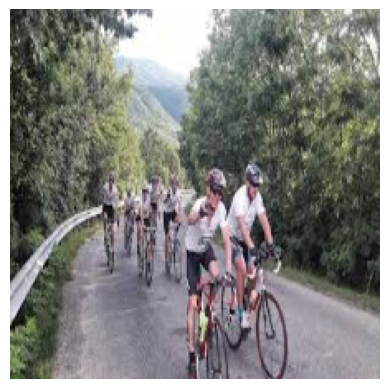

In [ ]:
 #Display the image stored in train_images[0] as an example
plt.imshow(train_images_full[3].astype('uint8'))  # Ensure the data is in uint8 format for proper display (pictures saved as a np array of numirical values )
plt.axis('off')  # Hide axes (not needed for sjowing the picture)
plt.show()

In [ ]:
# Sử dụng len() để lấy số lượng ví dụ trong tập huấn luyện và kiểm tra
n_train = len(train_labels_full)  # Dữ liệu huấn luyện sau khi xáo trộn
n_test = len(test_labels_full)    # Dữ liệu kiểm tra sau khi xáo trộn

print("Number of training examples: {}".format(n_train))
print("Number of testing examples: {}".format(n_test))
print("Each image is of size: {}".format(IMAGE_SIZE))


Number of training examples: 6000
Number of testing examples: 1200
Each image is of size: (150, 150)


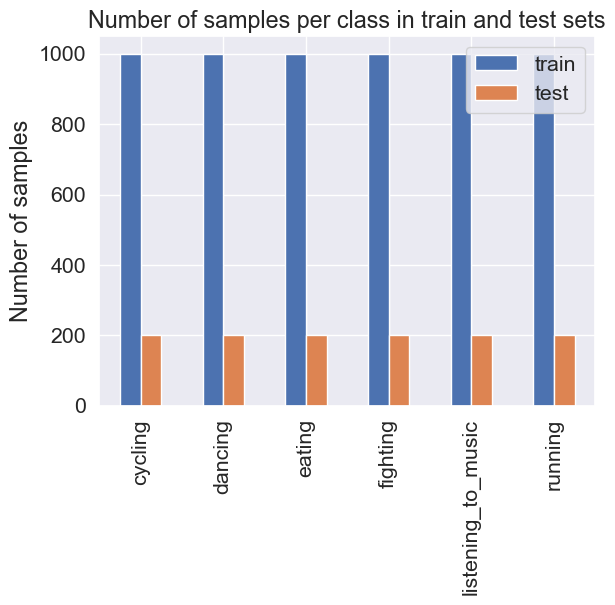

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đảm bảo bạn đang sử dụng test_labels_full và train_labels_full
_, train_counts = np.unique(train_labels_full, return_counts=True)
_, test_counts = np.unique(test_labels_full, return_counts=True)

# Tạo DataFrame và vẽ biểu đồ cột
pd.DataFrame({'train': train_counts,
              'test': test_counts},
             index=class_names).plot.bar()

# Hiển thị biểu đồ
plt.title("Number of samples per class in train and test sets")
plt.ylabel("Number of samples")
plt.show()


In [ ]:
# Chuẩn hóa (normalize) các giá trị pixel xuống [0, 1]
train_images_full = train_images_full / 255.0
test_images_full = test_images_full / 255.0


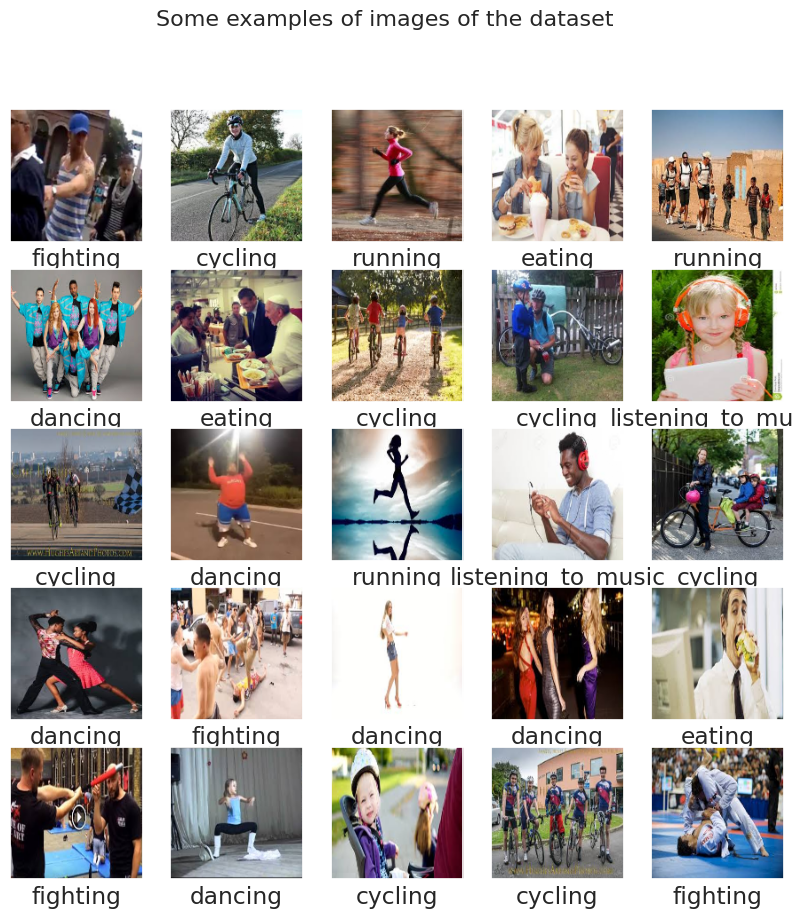

In [ ]:
def display_examples(class_names, images, labels):
    """
        Display 25 images from the images array with their corresponding labels
    """

    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])  # Ẩn các nhãn trục x
        plt.yticks([])  # Ẩn các nhãn trục y
        plt.grid(False)  # Tắt lưới
        plt.imshow(images[i], cmap=plt.cm.binary)  # Hiển thị hình ảnh
        plt.xlabel(class_names[labels[i]])  # Nhãn lớp của hình ảnh
    plt.show()

# Sử dụng hàm để hiển thị 25 ảnh ngẫu nhiên từ dữ liệu huấn luyện
display_examples(class_names, train_images_full, train_labels_full)

# Hoặc nếu bạn muốn hiển thị từ dữ liệu kiểm tra
# display_examples(class_names, test_images_full, test_labels_full)


In [ ]:


# Điều chỉnh lại lớp đầu vào của mô hình để sử dụng kích thước ảnh mới
model = tf.keras.Sequential([
    # Lớp Conv1: 96 bộ lọc kích thước 11x11, stride 4
    tf.keras.layers.Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2),

    # Lớp Conv2: 256 bộ lọc kích thước 5x5
    tf.keras.layers.Conv2D(256, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2),

    # Lớp Conv3: 512 bộ lọc kích thước 3x3
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),

    # Lớp Conv4: 512 bộ lọc kích thước 3x3
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),

    # Lớp Conv5: 512 bộ lọc kích thước 3x3
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2),

    # Global Average Pooling thay vì Flatten
    tf.keras.layers.GlobalAveragePooling2D(),

    # Lớp Dense1: 8192 neuron, sử dụng ReLU
    tf.keras.layers.Dense(8192, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.6),  # Dropout để giảm overfitting

    # Lớp Dense2: 8192 neuron, sử dụng ReLU
    tf.keras.layers.Dense(8192, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.6),  # Dropout để giảm overfitting

    # Lớp Dense3: 6 neuron (cho bài toán phân loại 6 lớp)
    tf.keras.layers.Dense(6, activation='softmax')  # Sử dụng softmax cho phân loại đa lớp
])

# Compile mô hình với learning rate scheduler và optimizer mới
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,  # Learning rate ban đầu
    decay_steps=10000,  # Số bước giảm learning rate
    decay_rate=0.95,  # Tỷ lệ giảm
    staircase=True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Xem tổng quan mô hình
model.summary()

# Huấn luyện mô hình
history = model.fit(train_images_full , train_labels_full, batch_size=128, epochs=15, validation_split=0.2)


E:\Anaconda_Navigator\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8192)           │     4,202,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │    67,117,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │        49,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,925,638 (297.26 MB)

 Trainable params: 77,921,862 (297.25 MB)

 Non-trainable params: 3,776 (14.75 KB)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.2306 - loss: 61.0186 - val_accuracy: 0.1900 - val_loss: 21.1667
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.3353 - loss: 11.1621 - val_accuracy: 0.2367 - val_loss: 7.1231
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.3552 - loss: 5.0954 - val_accuracy: 0.1992 - val_loss: 4.2031
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.4080 - loss: 3.4468 - val_accuracy: 0.2075 - val_loss: 3.5884
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.4328 - loss: 2.8384 - val_accuracy: 0.2558 - val_loss: 3.5652
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.4731 - loss: 2.3192 - val_accuracy: 0.2033 - val_loss: 3.0000
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.4772 - loss: 2.0843 - val_accuracy: 0.2075 - val_loss: 3.0007
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.5169 - loss: 1.8032 - val_accuracy: 0.2183 

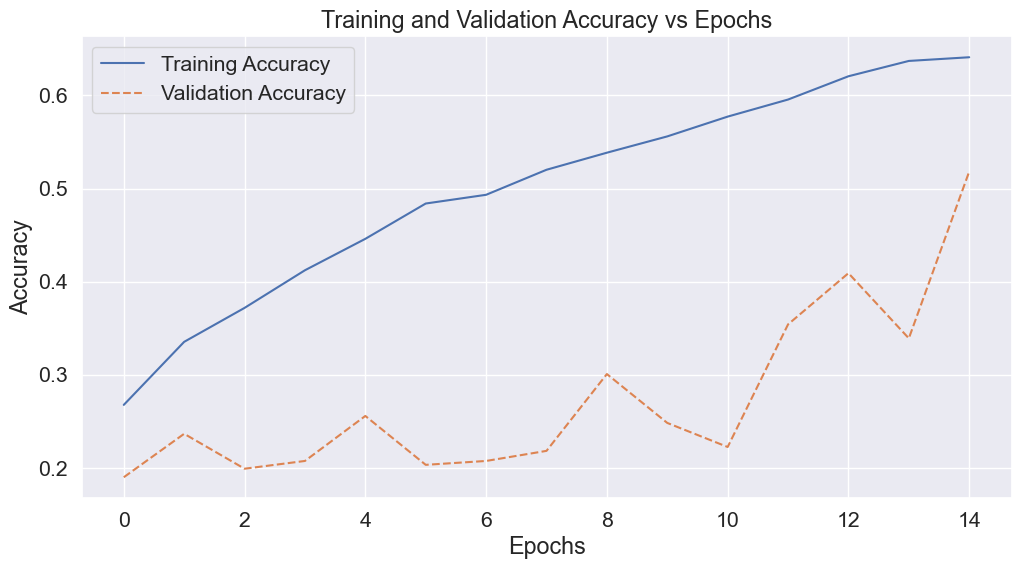

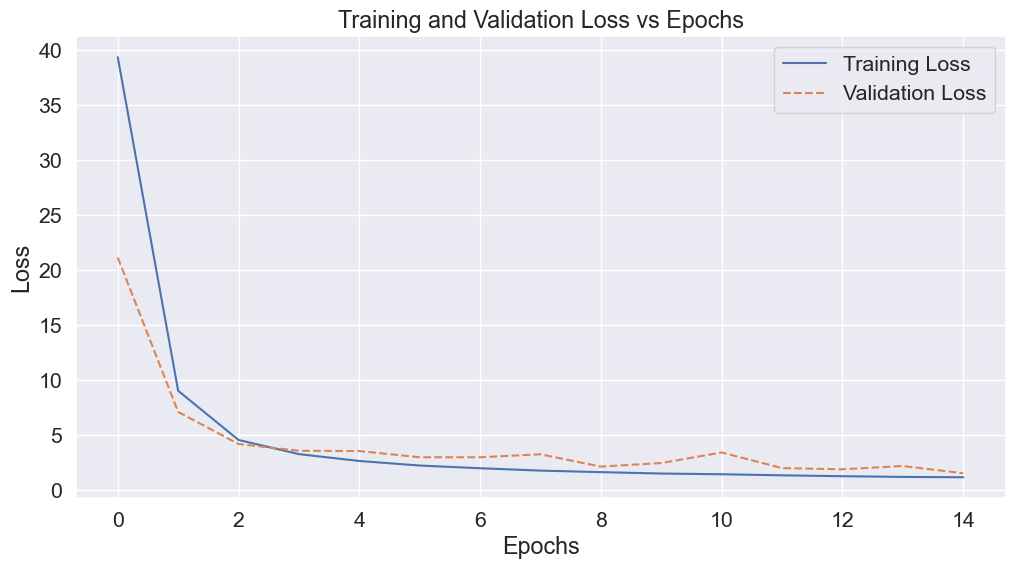

In [ ]:
import matplotlib.pyplot as plt

# Vẽ Training Accuracy vs. Epochs
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ Training/Validation Loss vs. Epochs
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Nếu bạn muốn vẽ Learning Rate, cần có callback theo dõi learning rate
# Sử dụng callback LearningRateScheduler hoặc ReduceLROnPlateau

# Giả sử bạn đã sử dụng LearningRateScheduler, bạn cần theo dõi và vẽ learning rate
# Đầu tiên, hãy tạo một list để lưu learning rate:
lr_history = history.history.get('lr', [])  # Nếu bạn đã sử dụng LearningRateScheduler

# Vẽ Learning Rate vs. Epochs
if lr_history:
    plt.figure(figsize=(12, 6))
    plt.plot(lr_history, label='Learning Rate')
    plt.title('Learning Rate vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_images_full, test_labels_full)
print('Test accuracy:', test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - accuracy: 0.4992 - loss: 1.6024
Test accuracy: 0.5233333110809326


38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 350ms/step


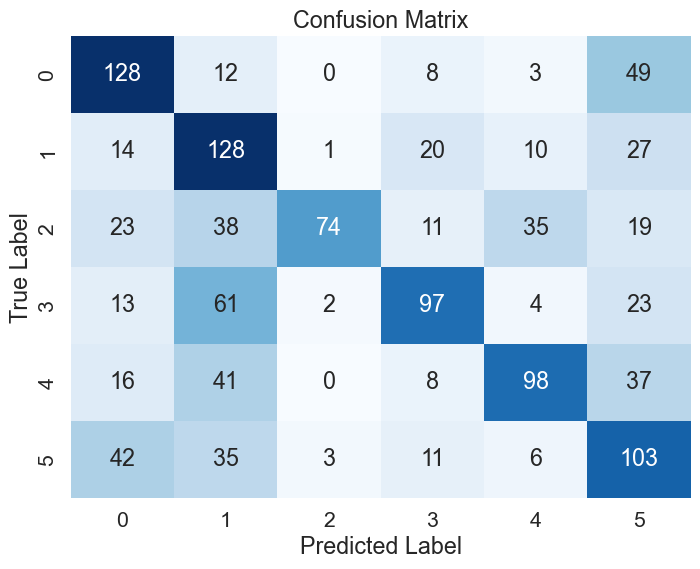

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_images_full)
y_pred_classes = np.argmax(y_pred, axis=1)


cm = confusion_matrix(test_labels_full, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(6), yticklabels=np.arange(6), cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()